In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [ ]:
df=df.iloc[:,2:]

In [ ]:
df.sample(5)

,Age,EstimatedSalary,Purchased
343,47,51000,1
375,46,32000,1
204,58,101000,1
345,41,63000,0
68,22,63000,0


#**Train Test split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((280, 2), (120, 2))

#**Standard Scalling**

In [ ]:
from pandas.core.tools.datetimes import Scalar
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
scalar.fit(X_train)
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [ ]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [ ]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [ ]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


Text(0.5, 1.0, 'After Scaling')

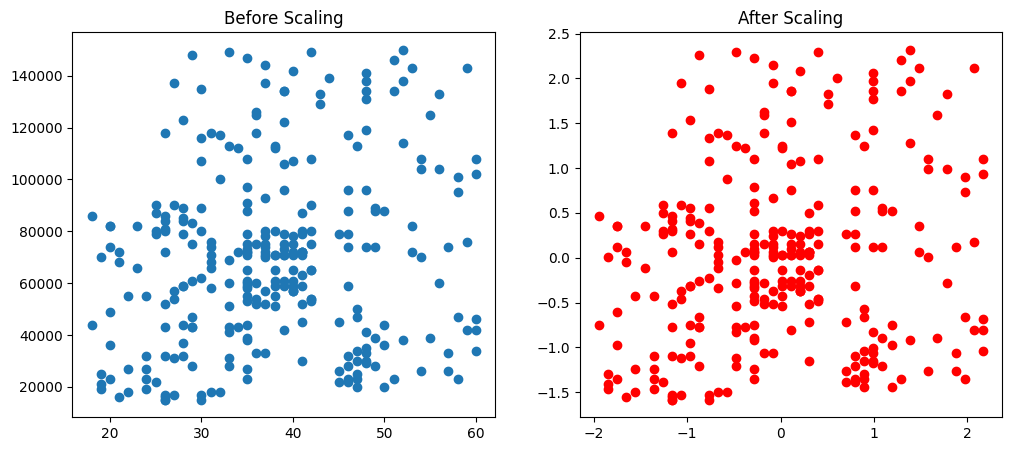

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Age'],X_train['EstimatedSalary'])
ax1.set_title('Before Scaling')
ax2.scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title('After Scaling')


<Axes: title={'center': 'After Scaling'}, xlabel='Age', ylabel='Density'>

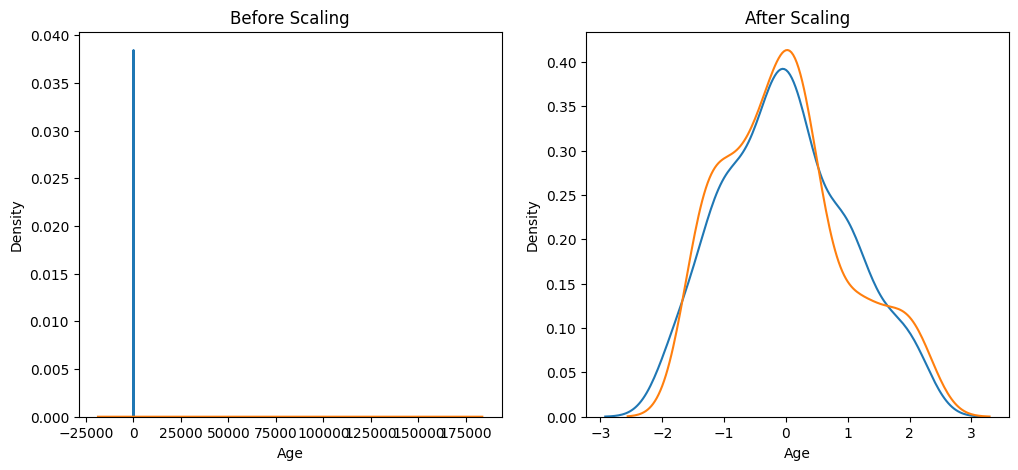

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'],ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)


<Axes: title={'center': 'After Scaling of Age'}, xlabel='Age', ylabel='Density'>

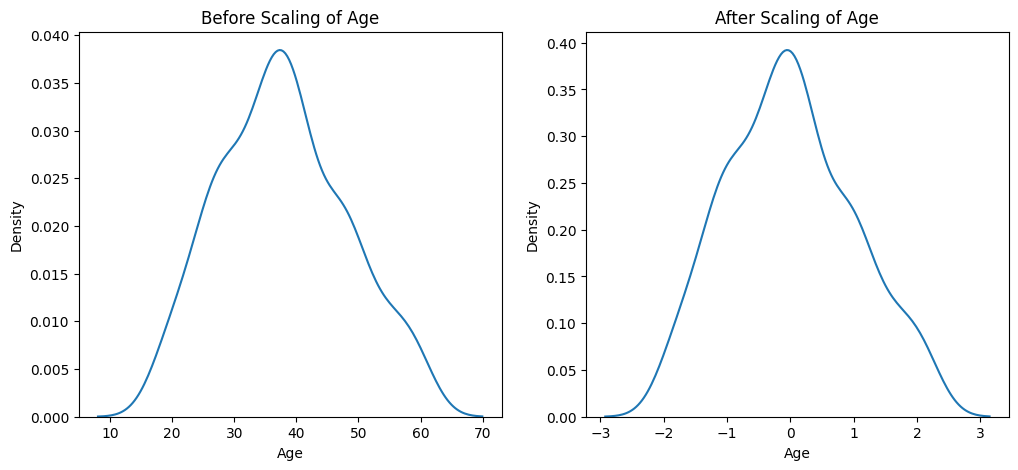

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title('Before Scaling of Age')
sns.kdeplot(X_train['Age'],ax=ax1)
ax2.set_title('After Scaling of Age')
sns.kdeplot(X_train_scaled['Age'],ax=ax2)

<Axes: title={'center': 'After Scaling of EstimatedSalary'}, xlabel='EstimatedSalary', ylabel='Density'>

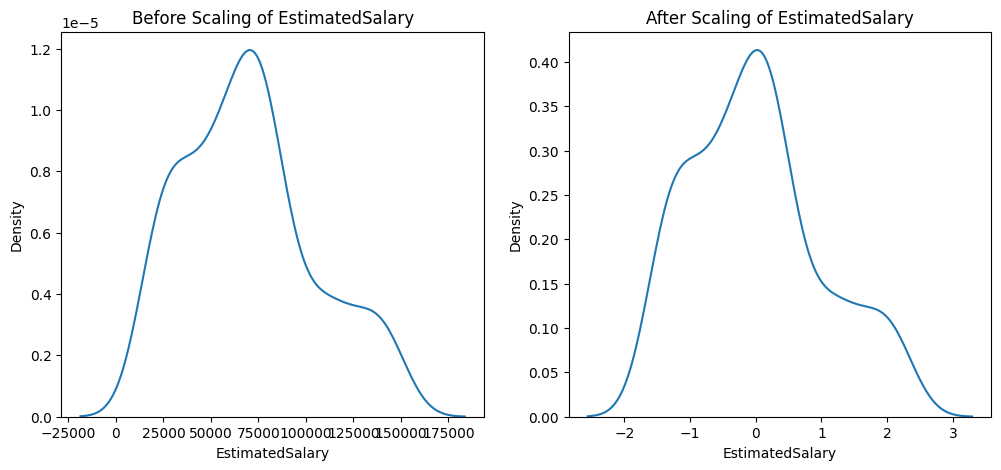

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title('Before Scaling of EstimatedSalary')
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1)
ax2.set_title('After Scaling of EstimatedSalary')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2)

#**Why scalling is important**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [ ]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
Y_pred=lr.predict(X_test)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [ ]:
print('Actual',accuracy_score(y_test,Y_pred))
print('Scaled',accuracy_score(y_test,Y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

In [ ]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [ ]:
Y_pred=dt.predict(X_test)
Y_pred_scaled=dt_scaled.predict(X_test_scaled)

In [ ]:
print('Actual',accuracy_score(y_test,Y_pred))
print('Scaled',accuracy_score(y_test,Y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667
